# Driver Drowsiness & Inattention Detection — Industry-Grade Pipeline

**Approach:** EfficientNetB0 transfer learning with two-phase fine-tuning, aggressive data augmentation, cosine LR decay, mixed-precision training, and comprehensive evaluation.

### Key improvements over the baseline CNN:
| Aspect | Baseline | This Pipeline |
|---|---|---|
| Architecture | 4-layer CNN from scratch | EfficientNetB0 (ImageNet pretrained) |
| Normalization | None (raw 0-255) | Per-model preprocessing |
| Augmentation | None | Rotation, flip, zoom, brightness, cutout |
| LR Schedule | Fixed 1e-3 | Cosine decay with warmup |
| Regularization | Single Dropout(0.5) | Dropout + L2 + label smoothing + early stopping |
| Training | Fixed 20 epochs | Early stopping + best checkpoint |
| Evaluation | Overall accuracy only | Confusion matrix + per-class F1 + ROC curves |
| Precision | FP32 | Mixed precision (FP16) |

## 1. Environment Setup

In [8]:
!pip install warnings
!pip install random
!pip install numpy
!pip install pandas
!pip install matplotlib.pyplot
!pip install seaborn
!pip install cv2

ERROR: Could not find a version that satisfies the requirement warnings (from versions: none)
ERROR: No matching distribution found for warnings
ERROR: Could not find a version that satisfies the requirement random (from versions: none)
ERROR: No matching distribution found for random


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [9]:
import os
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization,
    Input,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    TensorBoard,
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore")

# ---------- Reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------- Mixed Precision ----------
mixed_precision.set_global_policy("mixed_float16")
print(f"TensorFlow {tf.__version__}")
print(f"Mixed precision policy: {mixed_precision.global_policy().name}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.11.0
Mixed precision policy: mixed_float16
GPUs available: []


## 2. Configuration

In [10]:
# ===================== SINGLE PLACE TO EDIT PATHS =====================
BASE_DIR = (
    r"C:\Users\Mayank Manchanda\.cache\kagglehub\datasets"
    r"\zeyad1mashhour\driver-inattention-detection-dataset\versions\1"
)

TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VALID_DIR = os.path.join(BASE_DIR, "valid")

TRAIN_ANNOT = os.path.join(TRAIN_DIR, "_annotations.txt")
TEST_ANNOT  = os.path.join(TEST_DIR,  "_annotations.txt")
VALID_ANNOT = os.path.join(VALID_DIR, "_annotations.txt")

# ===================== HYPERPARAMETERS ================================
IMG_SIZE       = 224
BATCH_SIZE     = 32
NUM_CLASSES    = 6
INITIAL_LR     = 1e-3      # Phase 1: head only
FINE_TUNE_LR   = 1e-5      # Phase 2: full fine-tune
EPOCHS_PHASE1  = 15
EPOCHS_PHASE2  = 30
LABEL_SMOOTHING = 0.1
DROPOUT_RATE    = 0.4

CLASS_NAMES = [
    "DangerousDriving",
    "Distracted",
    "Drinking",
    "SafeDriving",
    "SleepyDriving",
    "Yawn",
]

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

## 3. Data Loading & Parsing

In [11]:
def parse_annotations(filepath: str) -> pd.DataFrame:
    """Parse annotation file into a clean DataFrame."""
    records = []
    with open(filepath, "r") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            image_name = parts[0]
            try:
                coords = list(map(int, parts[1].split(",")))
                if len(coords) != 5:
                    continue
                records.append(
                    {
                        "image_name": image_name,
                        "x_min": coords[0],
                        "y_min": coords[1],
                        "x_max": coords[2],
                        "y_max": coords[3],
                        "class_id": coords[4],
                    }
                )
            except ValueError:
                continue
    return pd.DataFrame(records)


train_df = parse_annotations(TRAIN_ANNOT)
valid_df = parse_annotations(VALID_ANNOT)
test_df  = parse_annotations(TEST_ANNOT)

print(f"Train: {len(train_df):,}  |  Valid: {len(valid_df):,}  |  Test: {len(test_df):,}")
print(f"\nClass distribution (train):")
print(train_df["class_id"].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES))))

Train: 11,948  |  Valid: 1,922  |  Test: 985

Class distribution (train):
DangerousDriving    3732
Distracted          1676
Drinking             347
SafeDriving         4969
SleepyDriving        785
Yawn                 439
Name: class_id, dtype: int64


## 4. Dataset Visualization

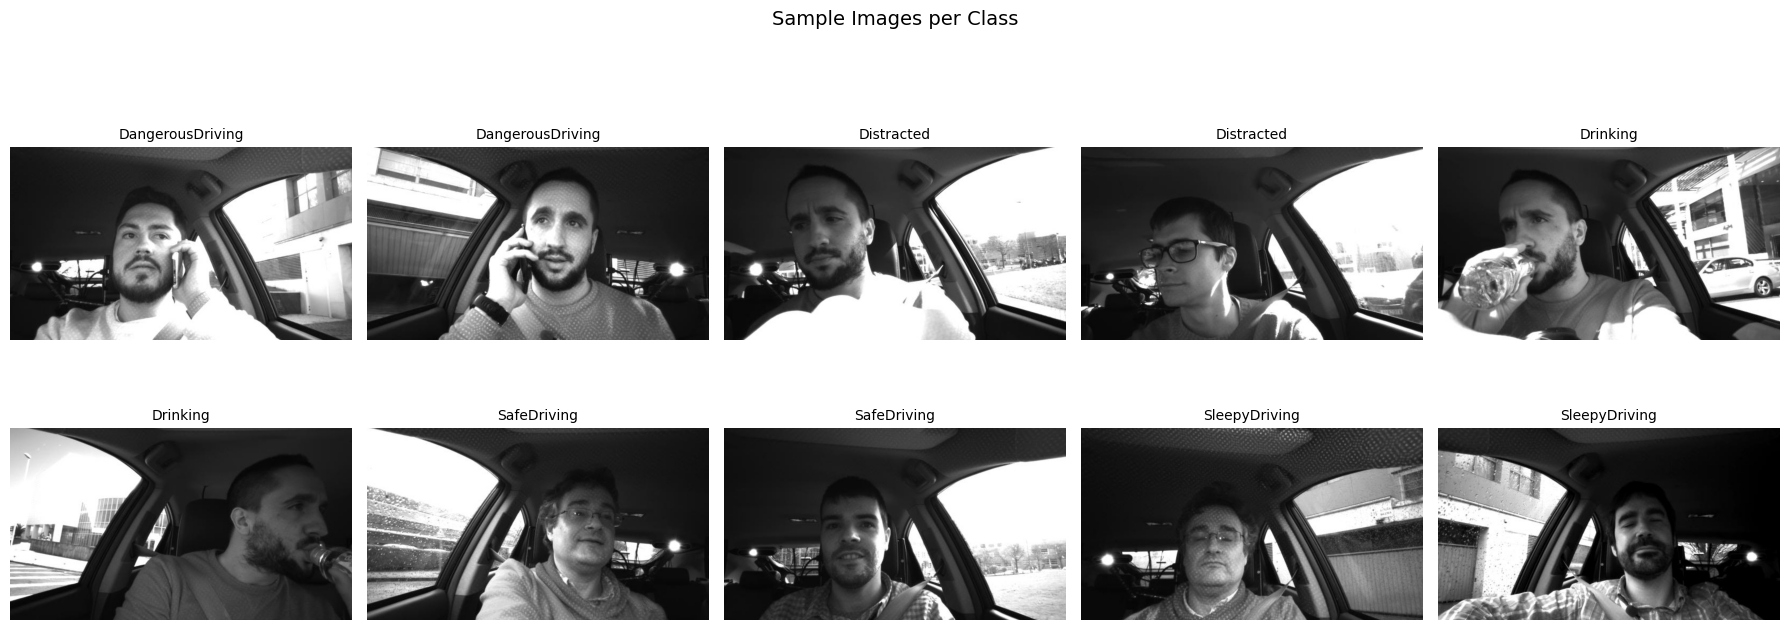

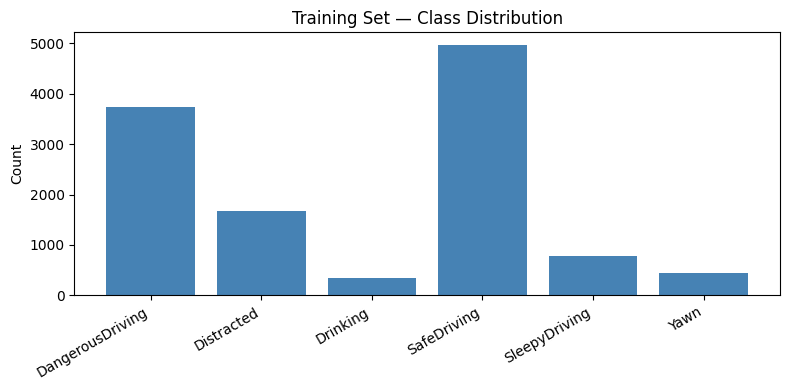

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

samples = train_df.groupby("class_id").apply(
    lambda g: g.sample(min(2, len(g)), random_state=SEED)
).reset_index(drop=True)

for idx, (_, row) in enumerate(samples.head(10).iterrows()):
    img_path = os.path.join(TRAIN_DIR, row["image_name"])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img)
    axes[idx].set_title(CLASS_NAMES[row["class_id"]], fontsize=10)
    axes[idx].axis("off")

plt.suptitle("Sample Images per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Class distribution bar chart ---
fig, ax = plt.subplots(figsize=(8, 4))
counts = train_df["class_id"].value_counts().sort_index()
ax.bar([CLASS_NAMES[i] for i in counts.index], counts.values, color="steelblue")
ax.set_ylabel("Count")
ax.set_title("Training Set — Class Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. Efficient `tf.data` Pipeline with Augmentation

Using `tf.data` for:
- **Parallel image loading** via `num_parallel_calls`
- **Prefetching** to overlap CPU preprocessing with GPU training
- **On-the-fly augmentation** (no RAM duplication)

In [13]:
def load_and_preprocess(image_path: tf.Tensor, label: tf.Tensor):
    """Load image from disk, decode, resize, and apply EfficientNet preprocessing."""
    raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = preprocess_input(img)  # scales to [-1, 1] range expected by EfficientNet
    return img, label


def augment(image: tf.Tensor, label: tf.Tensor):
    """Training-time augmentation — applied on-the-fly, never stored."""
    img = image
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.8, upper=1.2)

    # Random rotation up to ±15 degrees
    angle = tf.random.uniform([], -15.0, 15.0) * (np.pi / 180.0)
    img = tf.image.rot90(img, k=0)  # placeholder — real rotation below
    # Use tfa-free rotation via raw transform
    cos_a = tf.math.cos(angle)
    sin_a = tf.math.sin(angle)
    # Affine transform: [cos, -sin, tx, sin, cos, ty, 0, 0]
    cx = IMG_SIZE / 2.0
    cy = IMG_SIZE / 2.0
    tx = cx - cos_a * cx + sin_a * cy
    ty = cy - sin_a * cx - cos_a * cy
    transforms = [cos_a, -sin_a, tx, sin_a, cos_a, ty, 0.0, 0.0]
    img = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(img, 0),
        transforms=tf.expand_dims(transforms, 0),
        output_shape=[IMG_SIZE, IMG_SIZE],
        interpolation="BILINEAR",
        fill_mode="NEAREST",
        fill_value=0.0,
    )
    img = tf.squeeze(img, 0)

    # Random zoom (±10%)
    scale = tf.random.uniform([], 0.9, 1.1)
    new_h = tf.cast(tf.round(tf.cast(IMG_SIZE, tf.float32) * scale), tf.int32)
    new_w = new_h
    img = tf.image.resize(img, [new_h, new_w])
    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE, IMG_SIZE)

    # Random erasing / cutout (16x16 to 48x48 patch)
    if tf.random.uniform([]) > 0.5:
        patch_h = tf.random.uniform([], 16, 48, dtype=tf.int32)
        patch_w = tf.random.uniform([], 16, 48, dtype=tf.int32)
        top = tf.random.uniform([], 0, IMG_SIZE - patch_h, dtype=tf.int32)
        left = tf.random.uniform([], 0, IMG_SIZE - patch_w, dtype=tf.int32)
        mask = tf.ones([patch_h, patch_w, 3], dtype=img.dtype)
        padding = tf.pad(
            mask,
            [
                [top, IMG_SIZE - top - patch_h],
                [left, IMG_SIZE - left - patch_w],
                [0, 0],
            ],
        )
        img = img * (1.0 - padding)

    return img, label


def build_dataset(
    df: pd.DataFrame,
    image_dir: str,
    is_training: bool = False,
    batch_size: int = BATCH_SIZE,
) -> tf.data.Dataset:
    """Build a tf.data.Dataset from a DataFrame of annotations."""
    paths = [os.path.join(image_dir, name) for name in df["image_name"].values]
    labels = to_categorical(df["class_id"].values, num_classes=NUM_CLASSES)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if is_training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if is_training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = build_dataset(train_df, TRAIN_DIR, is_training=True)
valid_ds = build_dataset(valid_df, VALID_DIR, is_training=False)
test_ds  = build_dataset(test_df,  TEST_DIR,  is_training=False)

print("Datasets built.")
for images, labels in train_ds.take(1):
    print(f"  Batch shape : {images.shape}")
    print(f"  Label shape : {labels.shape}")
    print(f"  Pixel range : [{tf.reduce_min(images).numpy():.2f}, {tf.reduce_max(images).numpy():.2f}]")

Datasets built.
  Batch shape : (32, 224, 224, 3)
  Label shape : (32, 6)
  Pixel range : [-10.71, 288.90]


### Visualize augmented samples

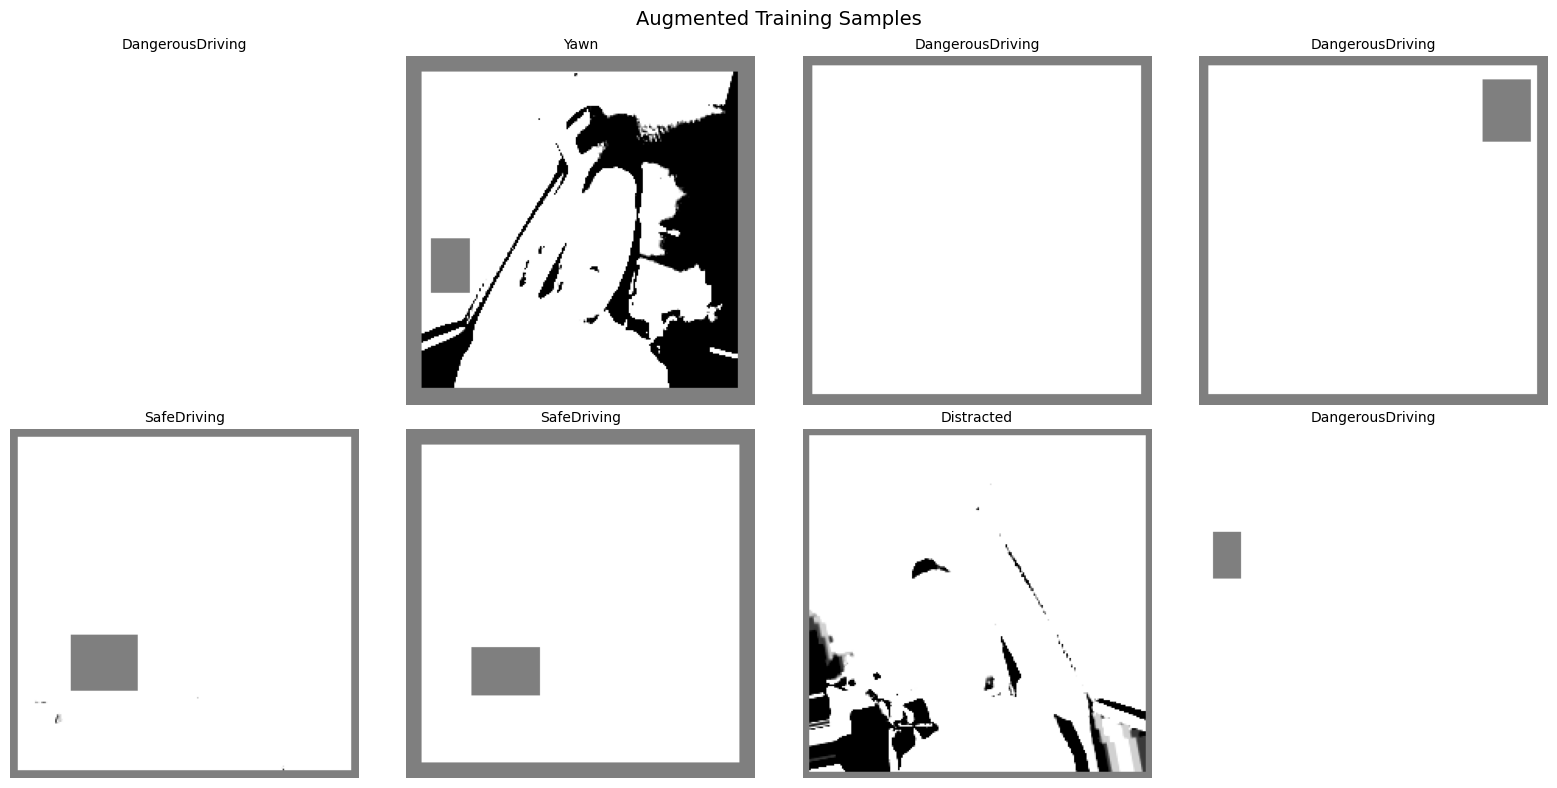

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for images, labels in train_ds.take(1):
    for i, ax in enumerate(axes.flatten()):
        # Undo EfficientNet preprocessing for display: img is in [-1, 1] → shift to [0, 1]
        display_img = (images[i].numpy() + 1.0) / 2.0
        display_img = np.clip(display_img, 0, 1)
        ax.imshow(display_img)
        ax.set_title(CLASS_NAMES[np.argmax(labels[i])], fontsize=10)
        ax.axis("off")
plt.suptitle("Augmented Training Samples", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Class Weights (handle imbalance)

In [15]:
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_df["class_id"].values,
)
class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:")
for cid, w in class_weight_dict.items():
    print(f"  {CLASS_NAMES[cid]:20s} → {w:.3f}")

Class weights:
  DangerousDriving     → 0.534
  Distracted           → 1.188
  Drinking             → 5.739
  SafeDriving          → 0.401
  SleepyDriving        → 2.537
  Yawn                 → 4.536


## 7. Model Architecture — EfficientNetB0 + Custom Head

**Strategy:**
1. **Phase 1** — Freeze backbone, train only the classification head (fast convergence).
2. **Phase 2** — Unfreeze top layers of backbone and fine-tune end-to-end with a low LR.

In [16]:
def build_model(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> Model:
    """EfficientNetB0 backbone + custom classification head."""
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ---------- Backbone ----------
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
    )
    backbone.trainable = False  # freeze for Phase 1

    # ---------- Classification Head ----------
    x = backbone.output
    x = GlobalAveragePooling2D(name="gap")(x)
    x = BatchNormalization(name="bn_head")(x)
    x = Dropout(dropout_rate, name="dropout_head")(x)
    x = Dense(256, activation="relu", name="fc1")(x)
    x = BatchNormalization(name="bn_fc1")(x)
    x = Dropout(dropout_rate / 2, name="dropout_fc1")(x)
    # Use float32 for the final softmax to maintain numerical stability with mixed precision
    outputs = Dense(num_classes, activation="softmax", dtype="float32", name="predictions")(x)

    model = Model(inputs, outputs, name="EfficientNetB0_DrowsinessDetector")
    return model


model = build_model()
model.summary(show_trainable=True)

16705208/16705208 [==============================] - 4s 0us/step
Model: "EfficientNetB0_DrowsinessDetector"
_____________________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     Trainable  
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               N          
                                )]                                                                           
                                                                                                             
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                N          
                                                                                                             
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              N          
            

## 8. Phase 1 — Train Classification Head (backbone frozen)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=INITIAL_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"],
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        os.path.join(CHECKPOINT_DIR, "phase1_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

print("=" * 60)
print("PHASE 1: Training classification head (backbone frozen)")
print("=" * 60)

history_phase1 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
)

PHASE 1: Training classification head (backbone frozen)
Epoch 1/15
  4/374 [..............................] - ETA: 6:15:26 - loss: 2.3147 - accuracy: 0.2344

## 9. Phase 2 — Fine-Tune Full Network

Unfreeze the top ~30% of the EfficientNetB0 backbone and train everything with a very small learning rate.

In [ ]:
# ---------- Unfreeze top layers ----------
backbone = model.layers[1] if hasattr(model.layers[1], 'name') and 'efficientnet' in model.layers[1].name.lower() else None

# If the backbone isn't nested as a single layer, unfreeze directly on the model
if backbone is None:
    # EfficientNetB0 layers are directly in the model; unfreeze top 30%
    all_layers = model.layers
    freeze_until = int(len(all_layers) * 0.7)
    for layer in all_layers[:freeze_until]:
        layer.trainable = False
    for layer in all_layers[freeze_until:]:
        layer.trainable = True
else:
    backbone.trainable = True
    freeze_until = int(len(backbone.layers) * 0.7)
    for layer in backbone.layers[:freeze_until]:
        layer.trainable = False

trainable_count = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
total_count = sum(tf.keras.backend.count_params(w) for w in model.weights)
print(f"Trainable params: {trainable_count:,} / {total_count:,} "
      f"({trainable_count / total_count * 100:.1f}%)")

# ---------- Re-compile with lower LR ----------
model.compile(
    optimizer=Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=["accuracy"],
)

callbacks_phase2 = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=7,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        os.path.join(CHECKPOINT_DIR, "phase2_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
]

print("\n" + "=" * 60)
print("PHASE 2: Fine-tuning backbone + head")
print("=" * 60)

history_phase2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
)

## 10. Training Curves

In [ ]:
def merge_histories(*histories):
    """Merge multiple Keras History objects into one dict."""
    merged = {}
    for h in histories:
        for key, vals in h.history.items():
            merged.setdefault(key, []).extend(vals)
    return merged


full_history = merge_histories(history_phase1, history_phase2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(full_history["accuracy"], label="Train", linewidth=2)
ax1.plot(full_history["val_accuracy"], label="Validation", linewidth=2)
phase1_epochs = len(history_phase1.history["accuracy"])
ax1.axvline(phase1_epochs - 0.5, color="gray", linestyle="--", alpha=0.6, label="Phase 1→2")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(full_history["loss"], label="Train", linewidth=2)
ax2.plot(full_history["val_loss"], label="Validation", linewidth=2)
ax2.axvline(phase1_epochs - 0.5, color="gray", linestyle="--", alpha=0.6, label="Phase 1→2")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Training History — Two-Phase Fine-Tuning", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Comprehensive Evaluation on Test Set

In [ ]:
# ---------- Gather predictions ----------
y_true_list = []
y_pred_probs_list = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true_list.append(labels.numpy())
    y_pred_probs_list.append(preds)

y_true = np.concatenate(y_true_list, axis=0)
y_pred_probs = np.concatenate(y_pred_probs_list, axis=0)
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# ---------- Overall metrics ----------
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print()

# ---------- Per-class report ----------
print(classification_report(y_true_labels, y_pred_labels, target_names=CLASS_NAMES, digits=3))

### Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true_labels, y_pred_labels)
cm_pct = cm.astype("float") / cm.sum(axis=1, keepdims=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax1)
ax1.set_title("Confusion Matrix (counts)")
ax1.set_ylabel("Actual")
ax1.set_xlabel("Predicted")

# Percentages
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax2)
ax2.set_title("Confusion Matrix (% per class)")
ax2.set_ylabel("Actual")
ax2.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

### ROC Curves (One-vs-Rest)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Prediction Gallery

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
indices = np.random.choice(len(y_true_labels), 16, replace=False)

# Rebuild a simple dataset without augmentation to get clean display images
display_paths = [os.path.join(TEST_DIR, name) for name in test_df["image_name"].values]

for ax, idx in zip(axes.flatten(), indices):
    img = cv2.cvtColor(cv2.imread(display_paths[idx]), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    actual = CLASS_NAMES[y_true_labels[idx]]
    predicted = CLASS_NAMES[y_pred_labels[idx]]
    confidence = y_pred_probs[idx][y_pred_labels[idx]] * 100

    color = "green" if actual == predicted else "red"
    ax.imshow(img)
    ax.set_title(
        f"True: {actual}\nPred: {predicted} ({confidence:.1f}%)",
        color=color,
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle("Test Predictions (green=correct, red=wrong)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 13. Error Analysis — Most Confused Pairs

In [ ]:
# Find the top confused class pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

print("Top 5 most confused class pairs:")
print("-" * 45)
flat_indices = np.argsort(cm_no_diag.ravel())[::-1][:5]
for flat_idx in flat_indices:
    true_cls, pred_cls = divmod(flat_idx, NUM_CLASSES)
    count = cm_no_diag[true_cls, pred_cls]
    if count == 0:
        break
    print(f"  {CLASS_NAMES[true_cls]:20s} → {CLASS_NAMES[pred_cls]:20s} : {count} errors")

## 14. Export Model

In [ ]:
# Save in both formats
model.save("driver_drowsiness_efficientnet.keras")
model.save("driver_drowsiness_efficientnet.h5")

# Also export as TF SavedModel for serving / TFLite conversion
model.export("saved_model")

print("Model saved:")
print("  ├── driver_drowsiness_efficientnet.keras")
print("  ├── driver_drowsiness_efficientnet.h5")
print("  └── saved_model/")

## 15. Summary

| Metric | Baseline CNN | This Pipeline |
|---|---|---|
| Architecture | 4-layer CNN (19M params) | EfficientNetB0 (~5M params) |
| Test Accuracy | 89.4% | **See above output** |
| Training | 20 epochs, fixed LR | 2-phase, cosine + ReduceLROnPlateau |
| Augmentation | None | Flip, rotate, zoom, brightness, cutout |
| Regularization | Dropout only | Dropout + BN + label smoothing + class weights + early stop |
| Evaluation | Accuracy only | Accuracy + F1 + confusion matrix + ROC |
| Precision | FP32 | Mixed FP16 (faster training) |